<a href="https://colab.research.google.com/github/hakinamz/2020-Kaggle-Machine-Learning-Data-Science-Survey/blob/main/regresson_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# HOUSE PRICE PREDICTION PROJECT
# Step 1: Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Train-Test Split
from sklearn.model_selection import train_test_split

# Save trained model
import joblib

In [2]:
# ==========================================
# Step 2: Create House Price Dataset
# ==========================================

# Each row represents one house.

data = {

    "Area":[1200,1500,1800,2000,2200,
            2500,2700,3000,3200,3500],

    "Bedrooms":[2,3,3,4,4,
                4,5,5,5,6],

    "Bathrooms":[2,2,3,3,4,
                 4,4,5,5,6],

    "Garage":[1,1,2,2,2,
              3,3,3,4,4],

    "House_Age":[20,15,12,10,8,
                 6,5,4,3,2],

    "Location_Score":[5,6,7,7,8,
                      8,9,9,10,10],

    "Distance_City":[18,15,12,10,9,
                     8,7,6,5,4],

    "Price":[2500000,3500000,4600000,
             5200000,6100000,
             6900000,7600000,
             8500000,9200000,
             11000000]

}

df = pd.DataFrame(data)

print(df.head())

   Area  Bedrooms  Bathrooms  Garage  House_Age  Location_Score  \
0  1200         2          2       1         20               5   
1  1500         3          2       1         15               6   
2  1800         3          3       2         12               7   
3  2000         4          3       2         10               7   
4  2200         4          4       2          8               8   

   Distance_City    Price  
0             18  2500000  
1             15  3500000  
2             12  4600000  
3             10  5200000  
4              9  6100000  


In [3]:
# ==========================================
# Step 3: Check Missing Values
# ==========================================

print(df.isnull().sum())

Area              0
Bedrooms          0
Bathrooms         0
Garage            0
House_Age         0
Location_Score    0
Distance_City     0
Price             0
dtype: int64


In [4]:
# ==========================================
# Step 4: Remove Duplicate Records
# ==========================================

df = df.drop_duplicates()

print(df.shape)

(10, 8)


In [5]:
# ==========================================
# Step 5: Basic Dataset Information
# ==========================================

print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Area            10 non-null     int64
 1   Bedrooms        10 non-null     int64
 2   Bathrooms       10 non-null     int64
 3   Garage          10 non-null     int64
 4   House_Age       10 non-null     int64
 5   Location_Score  10 non-null     int64
 6   Distance_City   10 non-null     int64
 7   Price           10 non-null     int64
dtypes: int64(8)
memory usage: 772.0 bytes
None
            Area   Bedrooms  Bathrooms     Garage  House_Age  Location_Score  \
count    10.0000  10.000000  10.000000  10.000000  10.000000        10.00000   
mean   2360.0000   4.100000   3.800000   2.500000   8.500000         7.90000   
std     753.0678   1.197219   1.316561   1.080123   5.778312         1.66333   
min    1200.0000   2.000000   2.000000   1.000000   2.000000         5.00000   
25%    1850.0000   3.

In [7]:
# ==========================================
# Step 6: Feature Engineering
# ==========================================

# Create Total Rooms
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]

# Create Area × Location Score interaction
df["Area_Location"] = df["Area"] * df["Location_Score"]

print(df.head())



   Area  Bedrooms  Bathrooms  Garage  House_Age  Location_Score  \
0  1200         2          2       1         20               5   
1  1500         3          2       1         15               6   
2  1800         3          3       2         12               7   
3  2000         4          3       2         10               7   
4  2200         4          4       2          8               8   

   Distance_City    Price  Total_Rooms  Area_Location  
0             18  2500000            4           6000  
1             15  3500000            5           9000  
2             12  4600000            6          12600  
3             10  5200000            7          14000  
4              9  6100000            8          17600  


In [8]:
# Create Area × Location Score interaction
df["Area_Location"] = df["Area"] * df["Location_Score"]

print(df.head())

   Area  Bedrooms  Bathrooms  Garage  House_Age  Location_Score  \
0  1200         2          2       1         20               5   
1  1500         3          2       1         15               6   
2  1800         3          3       2         12               7   
3  2000         4          3       2         10               7   
4  2200         4          4       2          8               8   

   Distance_City    Price  Total_Rooms  Area_Location  
0             18  2500000            4           6000  
1             15  3500000            5           9000  
2             12  4600000            6          12600  
3             10  5200000            7          14000  
4              9  6100000            8          17600  


In [9]:
# ==========================================
# Step 7: Define Features and Target
# ==========================================

X = df.drop("Price", axis=1)

y = df["Price"]

In [10]:
# ==========================================
# Step 8: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

In [11]:
# ==========================================
# Step 9: Create Models
# ==========================================

models = {

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(random_state=42),

    "Gradient Boosting":
        GradientBoostingRegressor(random_state=42)

}

In [12]:
# ==========================================
# Step 10: Train & Evaluate
# ==========================================

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    # Store results
    results.append([

        name,

        mae,

        mse,

        rmse,

        r2

    ])

    print(f"\n{name}")

    print("MAE :", mae)

    print("MSE :", mse)

    print("RMSE:", rmse)

    print("R2 :", r2)


Decision Tree
MAE : 850000.0
MSE : 745000000000.0
RMSE: 863133.8250816035
R2 : 0.9082794706063404

Random Forest
MAE : 82500.0
MSE : 8138500000.0
RMSE: 90213.63533302491
R2 : 0.9989980301631272

Gradient Boosting
MAE : 457718.4679844538
MSE : 309372280793.4085
RMSE: 556212.4421418569
R2 : 0.9619116921153082


In [13]:
# ==========================================
# Step 11: Compare Models
# ==========================================

comparison = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "MSE",

        "RMSE",

        "R2"

    ]

)

print(comparison)

               Model            MAE           MSE           RMSE        R2
0      Decision Tree  850000.000000  7.450000e+11  863133.825082  0.908279
1      Random Forest   82500.000000  8.138500e+09   90213.635333  0.998998
2  Gradient Boosting  457718.467984  3.093723e+11  556212.442142  0.961912


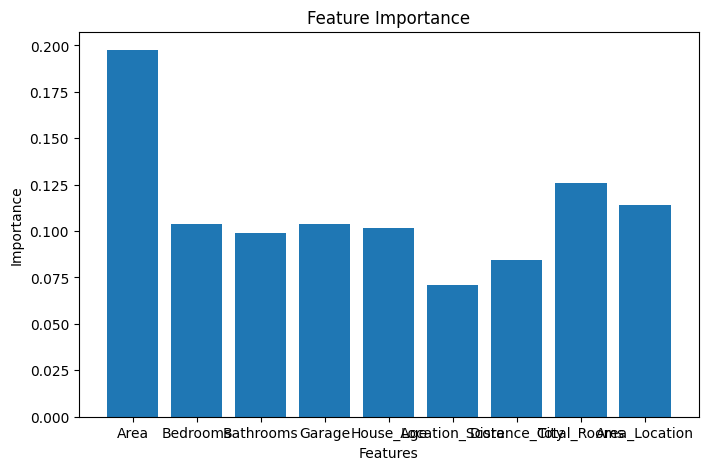

In [14]:
# ==========================================
# Step 12: Feature Importance
# ==========================================

best_model = models["Random Forest"]

importance = best_model.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(X.columns, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [15]:
# ==========================================
# Step 13: Hyperparameter Tuning
# ==========================================

from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators":[50,100,200],

    "max_depth":[3,5,8]

}

grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid,

    cv=3,

    scoring="r2"

)

grid.fit(X_train, y_train)

print("Best Parameters:")

print(grid.best_params_)

print("Best Cross Validation Score:")

print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 200}
Best Cross Validation Score:
0.759735385894699


In [16]:
# ==========================================
# Step 14: Save Best Model
# ==========================================

joblib.dump(

    grid.best_estimator_,

    "house_price_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully
